In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_review_order = pd.read_csv("../data/review_order_summary.csv")
df_review_order.head()

,order_id,review_score,total_price,total_freight
0,0005a1a1728c9d785b8e2b08b904576c,1.0,145.95,11.65
1,000aed2e25dbad2f9ddb70584c5a2ded,1.0,144.00,8.77
2,00169e31ef4b29deaae414f9a5e95929,1.0,39.00,16.11
3,0017afd5076e074a48f1f1a4c7bac9c5,1.0,809.10,44.29
4,001d8f0e34a38c37f7dba2a37d4eba8b,1.0,37.98,15.56


In [3]:
df_review_order.shape

(97917, 4)

In [5]:

# 欠損地の確認
df_review_order.isnull().sum()

order_id         0
review_score     0
total_price      0
total_freight    0
dtype: int64

In [6]:
# レビュー点数ごとの件数
df_review_order["review_score"].value_counts().sort_index()


review_score
1.0    10778
2.0     3071
3.0     8117
4.0    19012
5.0    56939
Name: count, dtype: int64

In [ ]:
# データ構造を確認
df_review_order.info()

In [7]:
# データの基本統計量を確認
df_review_order[["total_price", "total_freight"]].describe()

,total_price,total_freight
count,97917.000000,97917.000000
mean,137.534289,22.804014
std,209.482616,21.621022
min,0.850000,0.000000
25%,45.900000,13.840000
50%,86.900000,17.160000
75%,149.900000,24.010000
max,13440.000000,1794.960000


In [8]:
# レビューごとの記述統計
df_review_order.groupby("review_score")[["total_price", "total_freight"]].describe()

total_price                                                      \
                   count        mean         std   min    25%    50%     75%   
review_score                                                                   
1.0              10778.0  166.972587  287.663347  3.54  49.99  99.00  177.00   
2.0               3071.0  145.667105  219.929939  5.31  49.00  89.90  159.99   
3.0               8117.0  127.544890  167.868505  3.50  44.90  82.94  148.70   
4.0              19012.0  132.463578  195.481686  0.85  45.00  84.00  148.90   
5.0              56939.0  134.640429  200.549691  0.85  45.00  84.99  149.65   

                      total_freight                                            \
                  max         count       mean        std  min    25%     50%   
review_score                                                                    
1.0           13440.0       10778.0  27.749845  29.928212  0.0  15.10  18.455   
2.0            3999.0        3071.0  26.279326  26.289365  0.0  14.52  18.020   
3.0            2919.4        8117.0  23.570729  22.291298  0.0  14.10  17.630   
4.0            4690.0       19012.0  22.372474  19.415611  0.0  13.89  17.180   
5.0            6735.0       56939.0  21.715167  19.844330  0.0  13.49  16.790   

                               
                 75%      max  
review_score                   
1.0           31.115  1002.29  
2.0           29.015   456.47  
3.0           25.300   626.64  
4.0           23.780   479.28  
5.0           23.130  1794.96

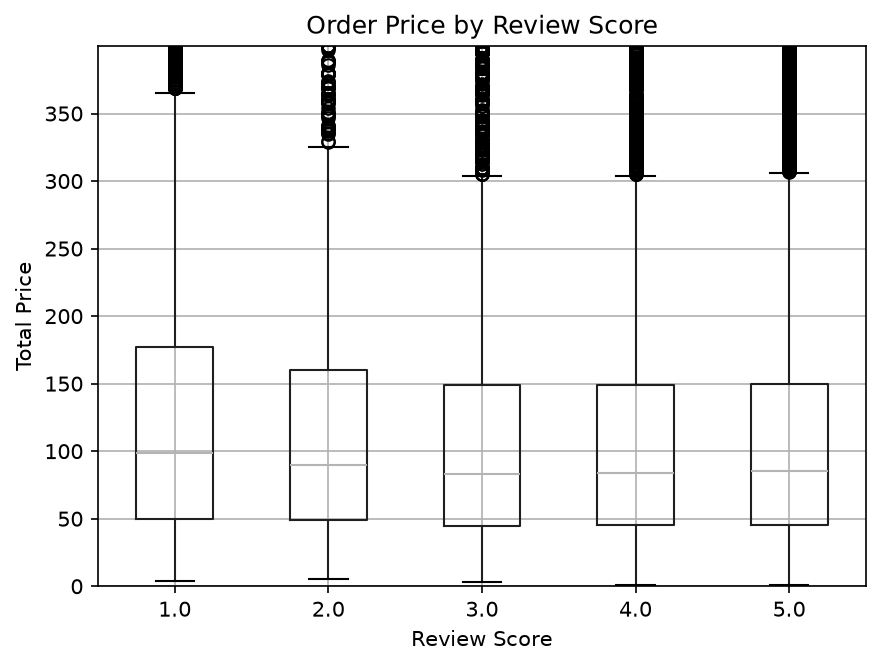

In [11]:
# レビュー点数別の注文金額を箱ひげ図で確認
price_95 = df_review_order["total_price"].quantile(0.95)  # 95パーセンタイルの値を取得

df_review_order.boxplot(
    
    column="total_price", 
    by="review_score"
    )

plt.ylim(0, price_95)

#plt.yscale("log")  # y軸を対数スケールに設定
plt.title("Order Price by Review Score")
plt.suptitle("")  # デフォルトのタイトルを削除
plt.xlabel("Review Score")
plt.ylabel("Total Price")
plt.show()

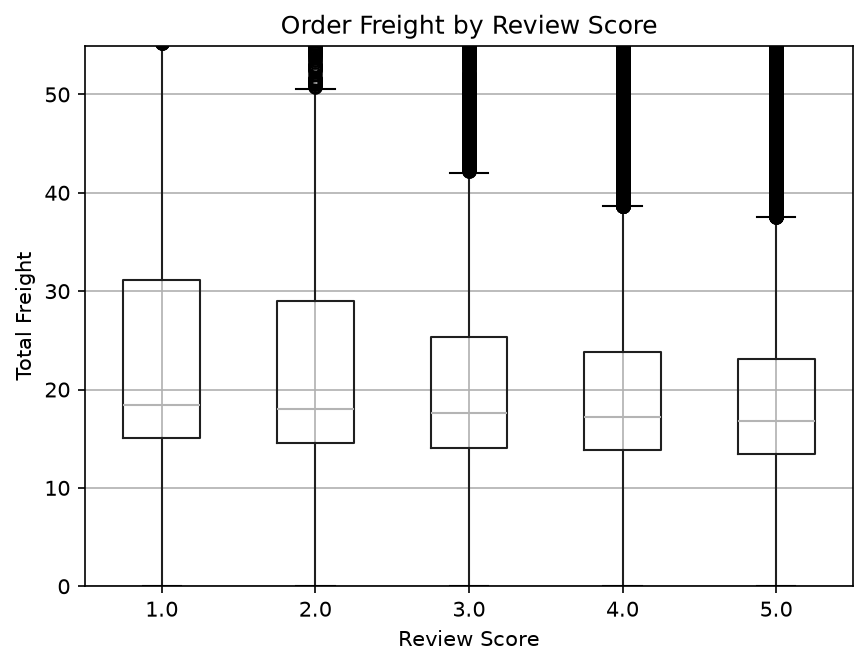

In [12]:
# 送料の箱ひげ図
freight_95 = df_review_order["total_freight"].quantile(0.95)  # 95パーセンタイルの値を取得

df_review_order.boxplot(
    column="total_freight",
    by="review_score"
)
plt.ylim(0, freight_95)

plt.title("Order Freight by Review Score")
plt.suptitle("")
plt.xlabel("Review Score")
plt.ylabel("Total Freight")
plt.show()

In [9]:
from scipy.stats import kruskal

groups_price = [
    group["total_price"].values
    for _, group in df_review_order.groupby("review_score")
]

stat_price, p_price = kruskal(*groups_price)

print("=== Kruskal-Wallis Test ===")
print()
print("[Total Price]")
print(f"H-statistic: {stat_price:.4f}")
print(f"p-value: {p_price:.6g}")

=== Kruskal-Wallis Test ===

[Total Price]
H-statistic: 299.1710
p-value: 1.63538e-63


In [10]:
# total_freightの分布がレビュー点数ごとに異なるかどうかを検定
groups_freight = [
    group["total_freight"].values
    for _, group in df_review_order.groupby("review_score")
]

stat_freight, p_freight = kruskal(*groups_freight)

print()
print("[Total Freight]")
print(f"H-statistic: {stat_freight:.4f}")
print(f"p-value: {p_freight:.6g}")


[Total Freight]
H-statistic: 932.2902
p-value: 1.67964e-200


In [ ]:
# Dunnettの方法で価格を多重比較
import scikit_posthocs as sp

dunn_price = sp.posthoc_dunn(
    df_review_order,
    val_col="total_price",
    group_col="review_score",
    p_adjust="bonferroni"
)

dunn_price

,1.0,2.0,3.0,4.0,5.0
1.0,1.000000e+00,0.000061,1.323318e-36,5.288514e-48,3.336384e-57
2.0,6.092683e-05,1.000000,6.078887e-05,1.273316e-04,3.699173e-04
3.0,1.323318e-36,0.000061,1.000000e+00,1.000000e+00,1.000000e+00
4.0,5.288514e-48,0.000127,1.000000e+00,1.000000e+00,1.000000e+00
5.0,3.336384e-57,0.000370,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
# Dunnettの方法で送料を多重比較

dunn_freight = sp.posthoc_dunn(
    df_review_order,
    val_col="total_freight",
    group_col="review_score",
    p_adjust="bonferroni"
)

dunn_freight

,1.0,2.0,3.0,4.0,5.0
1.0,1.000000e+00,8.253990e-04,1.448009e-35,7.153991e-90,4.208144e-179
2.0,8.253990e-04,1.000000e+00,7.049401e-06,4.762339e-16,1.514409e-31
3.0,1.448009e-35,7.049401e-06,1.000000e+00,1.161491e-04,3.255574e-21
4.0,7.153991e-90,4.762339e-16,1.161491e-04,1.000000e+00,1.140032e-10
5.0,4.208144e-179,1.514409e-31,3.255574e-21,1.140032e-10,1.000000e+00


In [5]:
# レビュー点数ごとの中央値を確認

summary = (
    df_review_order
    .groupby("review_score")[["total_price", "total_freight"]]
    .agg(["mean", "median"])
)

summary

total_price        total_freight        
                    mean median          mean  median
review_score                                         
1.0           166.972587  99.00     27.749845  18.455
2.0           145.667105  89.90     26.279326  18.020
3.0           127.544890  82.94     23.570729  17.630
4.0           132.463578  84.00     22.372474  17.180
5.0           134.640429  84.99     21.715167  16.790

In [ ]:
# レビュー5点を基準に、レビュー点数ごとの中央値の差を確認

median_summary = (
    df_review_order
    .groupby("review_score")[["total_price", "total_freight"]]
    .median()
)

median_summary["price_diff_vs_5"] = (
    median_summary["total_price"]
    - median_summary.loc[5, "total_price"]
)

median_summary["freight_diff_vs_5"] = (
    median_summary["total_freight"]
    - median_summary.loc[5, "total_freight"]
)

median_summary

,total_price,total_freight,price_diff_vs_5,freight_diff_vs_5
review_score,,,,
1.0,99.00,18.455,14.01,1.665
2.0,89.90,18.020,4.91,1.230
3.0,82.94,17.630,-2.05,0.840
4.0,84.00,17.180,-0.99,0.390
5.0,84.99,16.790,0.00,0.000


In [7]:
# レビュー5点を基準に、レビュー点数ごとの平均値の差を確認

mean_summary = (
    df_review_order
    .groupby("review_score")[["total_price", "total_freight"]]
    .mean()
)

mean_summary["price_diff_vs_5"] = (
    mean_summary["total_price"]
    - mean_summary.loc[5, "total_price"]
)

mean_summary["freight_diff_vs_5"] = (
    mean_summary["total_freight"]
    - mean_summary.loc[5, "total_freight"]
)

mean_summary

,total_price,total_freight,price_diff_vs_5,freight_diff_vs_5
review_score,,,,
1.0,166.972587,27.749845,32.332158,6.034678
2.0,145.667105,26.279326,11.026676,4.564159
3.0,127.544890,23.570729,-7.095539,1.855562
4.0,132.463578,22.372474,-2.176851,0.657307
5.0,134.640429,21.715167,0.000000,0.000000


In [11]:
# Kruskal-Wallis統計量とグループ数 (k)、全サンプル数 (n) を基に、効果量ε²を計算

n = len(df_review_order)
k = df_review_order["review_score"].nunique()

epsilon_price = (stat_price - k + 1) / (n - k)
epsilon_freight = (stat_freight - k + 1) / (n - k)

print(f"Total Price  ε²: {epsilon_price:.6f}")
print(f"Total Freight ε²: {epsilon_freight:.6f}")

Total Price  ε²: 0.003015
Total Freight ε²: 0.009481
